In [ ]:
import lightkurve as lk
import matplotlib.pyplot as plt

In [ ]:
search_k7 = lk.search_lightcurve("Kepler-7", mission="Kepler")
print(search_k7)

In [ ]:
lc_k7 = search_k7.download_all()
lc_k7_stitched = lc_k7.stitch()
lc_k7_stitched.plot()
plt.show()

In [ ]:
search_k7 = lk.search_lightcurve("Kepler-7", mission="Kepler", author="Kepler")
print(search_k7)

In [ ]:
lc_k7 = search_k7.download_all()
lc_k7_stitched = lc_k7.stitch()
lc_k7_stitched.plot()
plt.show()

In [ ]:
lc_k7_clean = lc_k7_stitched.remove_outliers(sigma=3)
lc_k7_flat, trend = lc_k7_clean.flatten(window_length=1001, polyorder=2, return_trend=True)
lc_k7_folded = lc_k7_flat.fold(period=4.88549, epoch_time=2454833.0+2454964.511)
lc_k7_binned = lc_k7_folded.bin(time_bin_size=0.005)

lc_k7_binned.plot()
plt.ylim(0.988, 1.002)
plt.xlim(-0.3, 0.3)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
lc_k7_folded2 = lc_k7_flat.fold(period=4.88549, epoch_time=2454833.0+2454964.911)
lc_k7_binned2 = lc_k7_folded2.bin(time_bin_size=0.005)

lc_k7_binned2.plot()
plt.ylim(0.988, 1.002)
plt.xlim(-0.3, 0.3)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
print(lc_k7_folded2.time[lc_k7_folded2.flux == lc_k7_folded2.flux.min()])

In [ ]:
lc_k7_folded2.plot()
plt.ylim(0.988, 1.002)
plt.show()

In [ ]:
lc_k7_binned_full = lc_k7_folded2.bin(time_bin_size=0.01)
lc_k7_binned_full.plot()
plt.ylim(0.988, 1.002)
plt.show()

In [ ]:
print(lc_k7_binned_full.flux.min())
print(lc_k7_binned_full.time[lc_k7_binned_full.flux == lc_k7_binned_full.flux.min()])

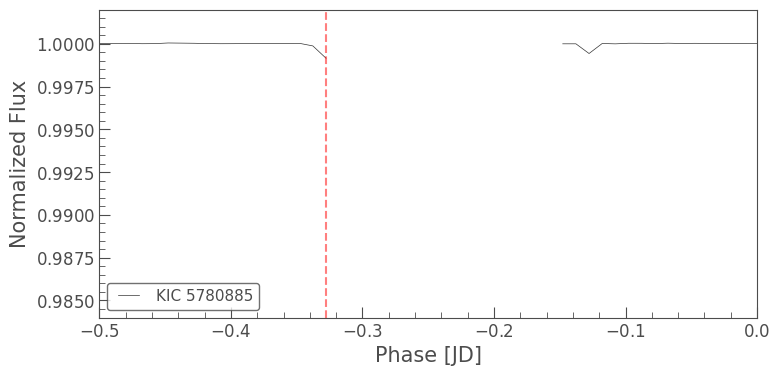

In [32]:
lc_k7_binned_full.plot()
plt.ylim(0.984, 1.002)
plt.xlim(-0.5, 0.0)
plt.axvline(x=-0.328, color='red', linestyle='--', alpha=0.5)
plt.show()

In [33]:
#observing dip, but gap is just meh, bec of incomplete data. 

In [34]:
import numpy as np

depth_k7 = 1.0 - lc_k7_binned_full.flux.min()
R_star_k7 = 1.843  # solar radii 
R_planet_k7 = R_star_k7 * np.sqrt(depth_k7) #get planet radius using formula
R_jupiter = 71492 #km
R_sun = 696340 #km
R_planet_km = R_planet_k7*R_sun
print(f"Depth: {depth_k7:.6f}")
print(f"Planet radius: {R_planet_k7:.4f} solar radii")
print(f"Planet radius: {R_planet_km:.0f} km")
print(f"Planet radius: {R_planet_km/R_jupiter:.2f} Jupiter radii")

Depth: 0.000842
Planet radius: 0.0535 solar radii
Planet radius: 37243 km
Planet radius: 0.52 Jupiter radii


In [35]:
depth_k7_true = 0.00961
R_planet_k7 = R_star_k7 * np.sqrt(depth_k7_true)
R_planet_km = R_planet_k7 * 696340

print(f"Planet radius: {R_planet_k7:.4f} solar radii")
print(f"Planet radius: {R_planet_km:.0f} km")
print(f"Planet radius: {R_planet_km/R_jupiter:.2f} Jupiter radii")

Planet radius: 0.1807 solar radii
Planet radius: 125808 km
Planet radius: 1.76 Jupiter radii
